# (二) 场景搭建
## (2) 快速搭建场景
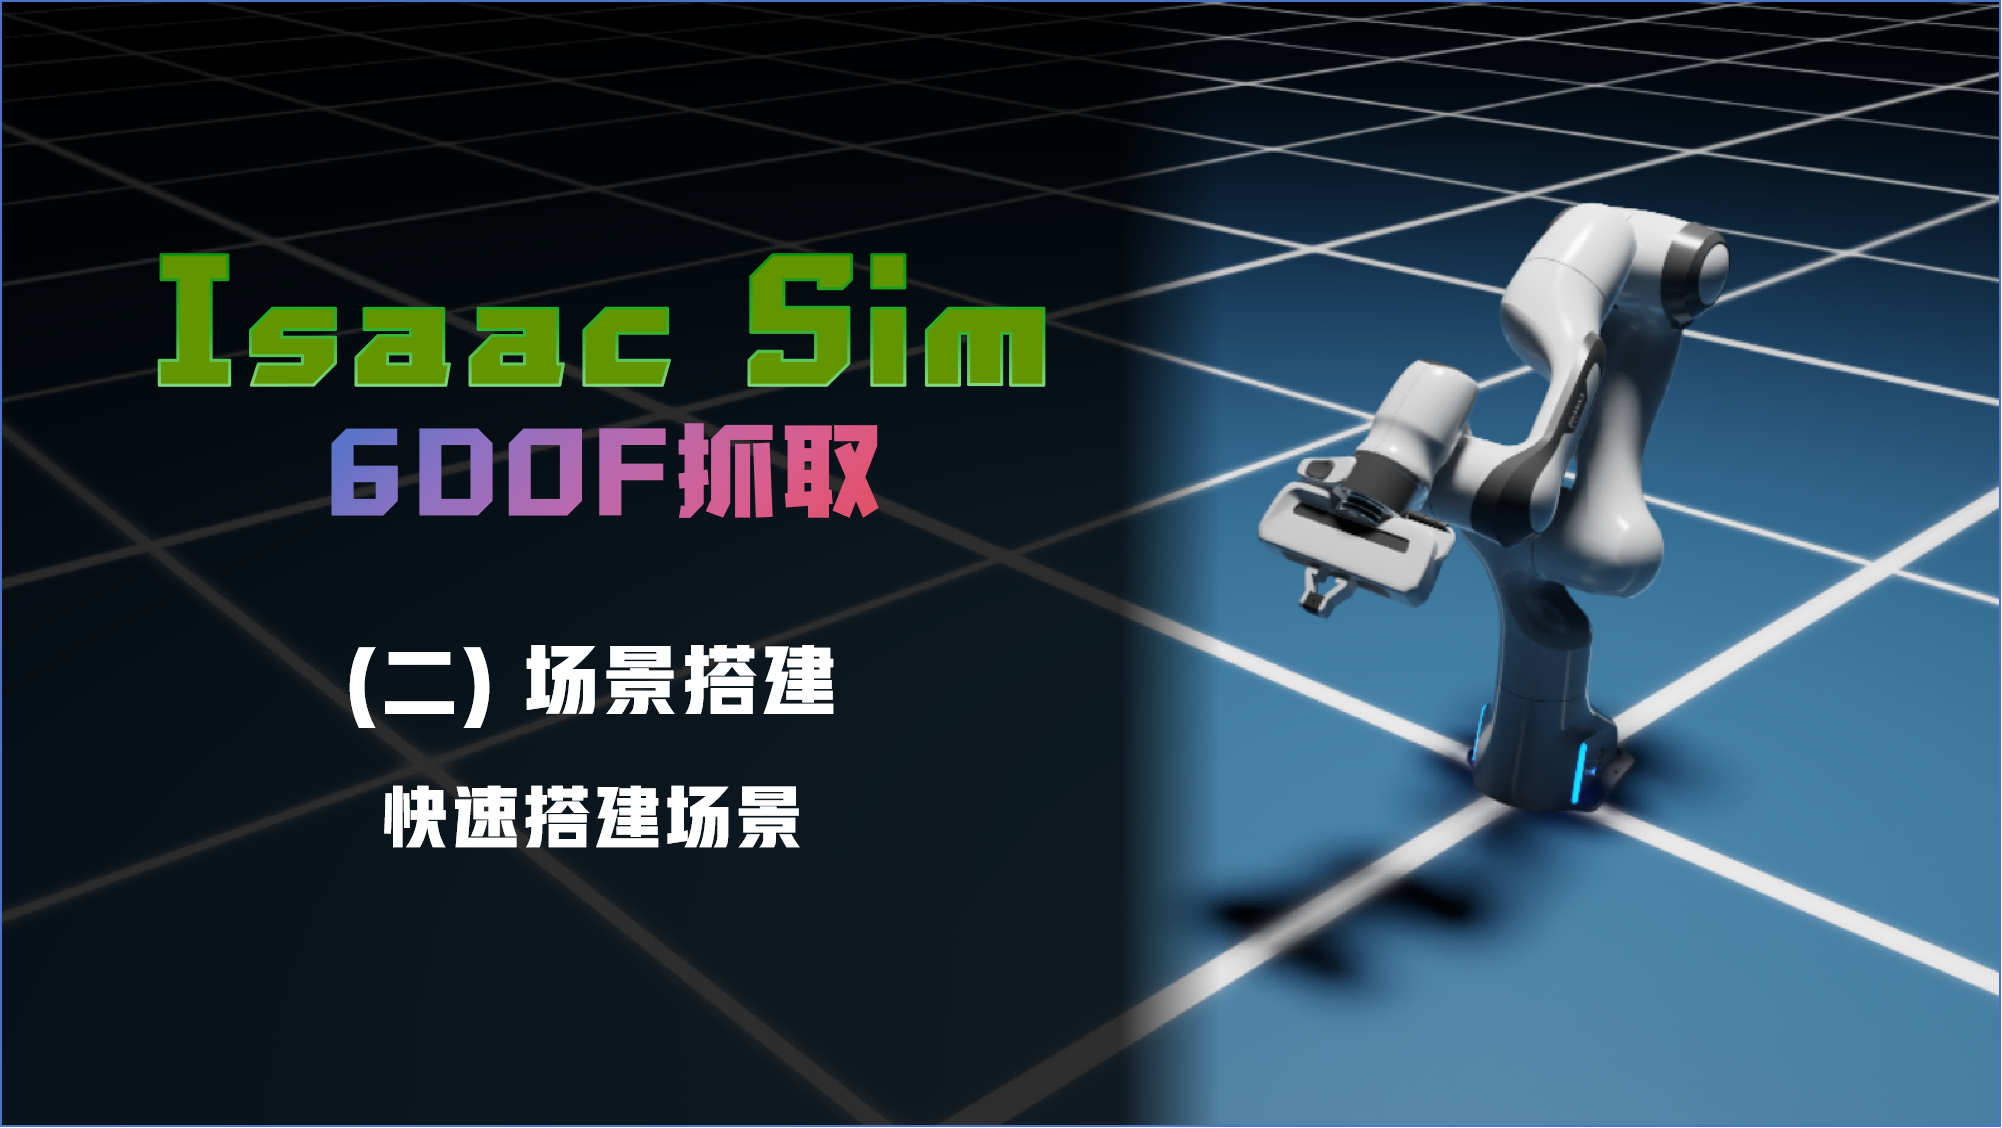
我们使用IsaacSim快速搭建场景，包括：
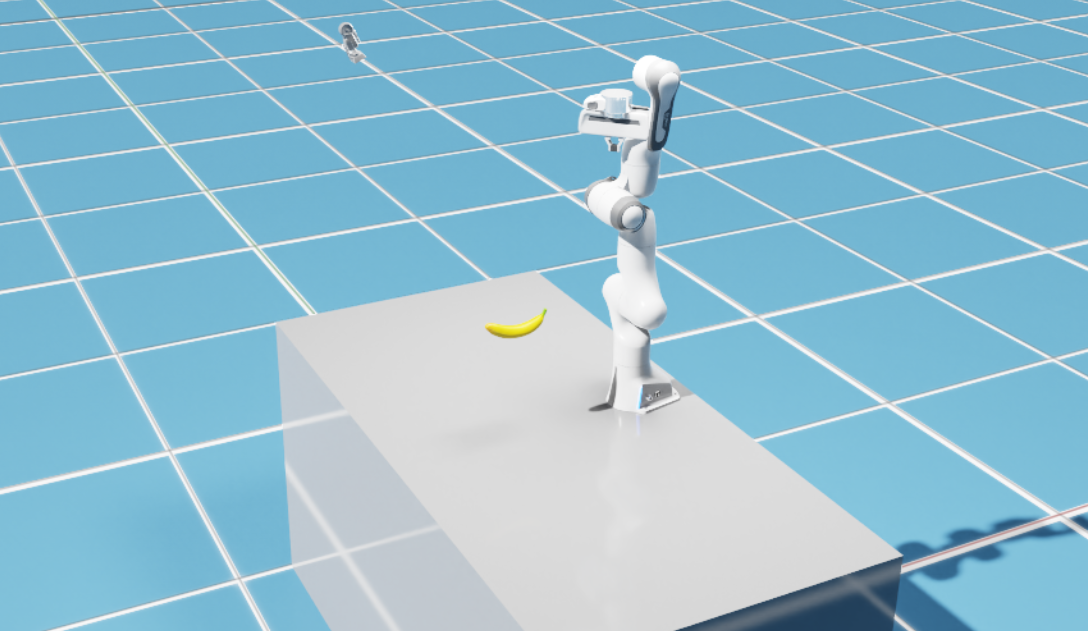
1. franka机械臂
2. 工作台
3. 待抓取物体：香蕉
4. 一台摄像机
5. （可选）地面 


工作台用一个Cube，franka的base坐标位于(0,0,1);

摄像机采取眼在手外的方式，在上方俯视工作台

## (3) 物理属性
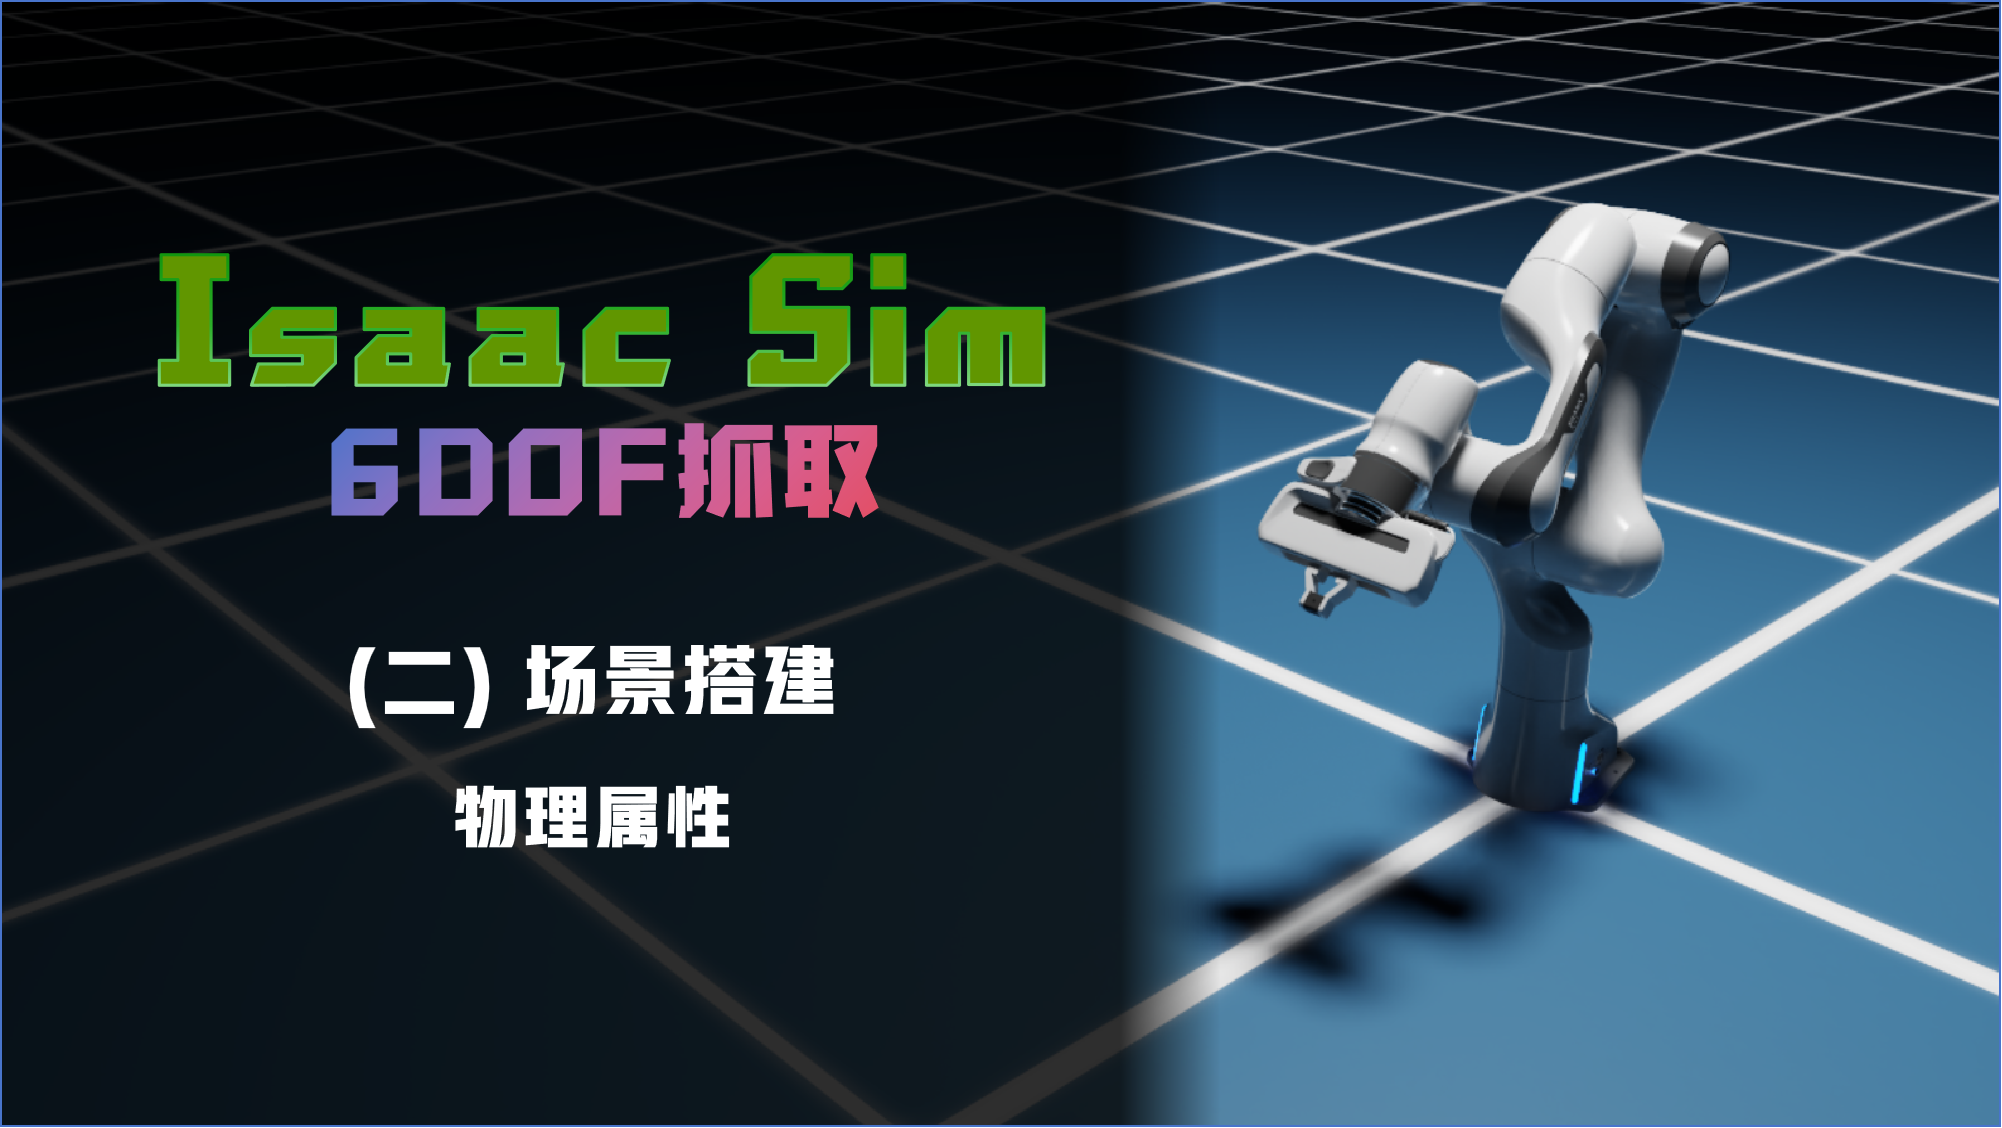

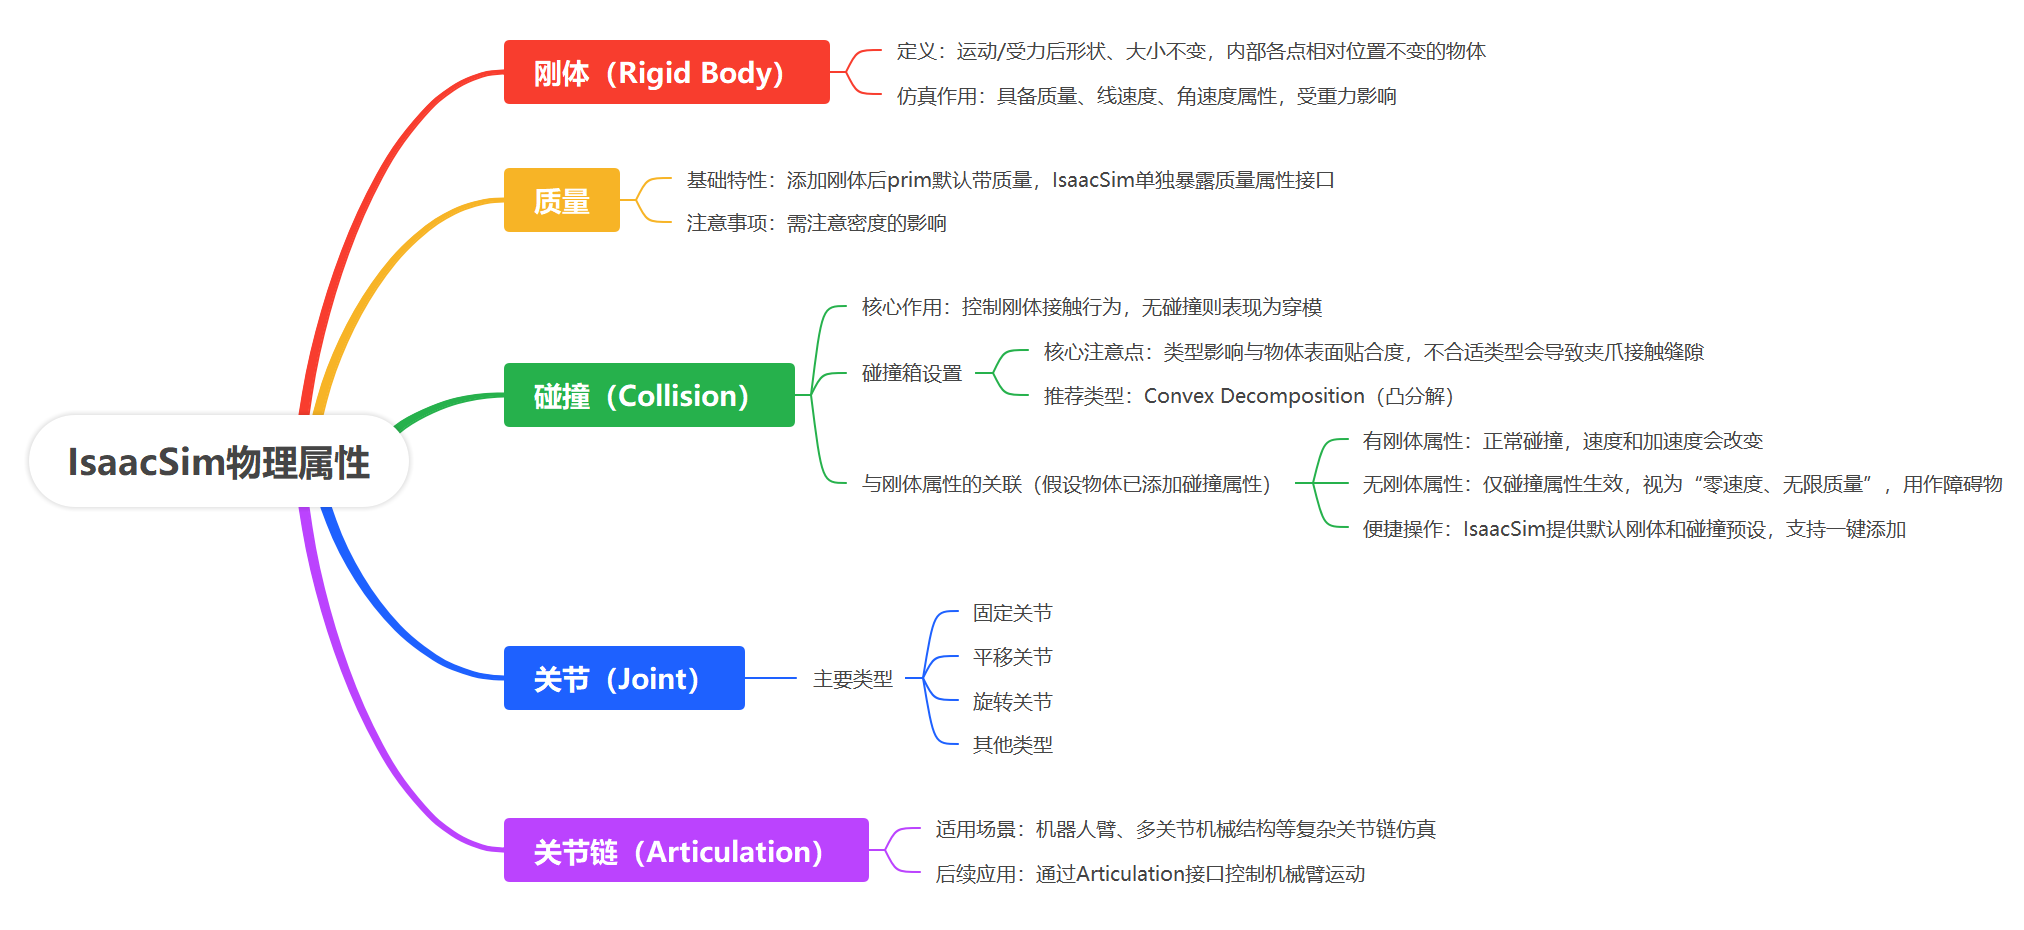

1. 刚体(Rigid Body)（刚体是指在运动中和受力作用后，形状和大小不变，而且内部各点的相对位置不变的物体。）
    * 在仿真中的主要作用是：拥有质量、线速度和角速度属性，受重力的影响
2. 质量
    * 尽管isaacsim中添加刚体后，prim就有质量，但是isaacsim单独暴露出质量属性接口
    * 需要注意密度的影响
3. 碰撞
   * 刚体接触时的行为，没有碰撞表现为穿模
   * 需要注意碰撞箱的设置类型
     * 不同的碰撞箱类型贴合物体表面不同，不合适的类型会导致夹爪接触会有缝隙
     * 一般使用(Convex Decomposition)
   * 和刚体的属性的结合，假设物体已经被添加了刚体属性
     * 如果添加了刚体属性
       * 那么刚体正常发生碰撞，并改变速度和加速度
     * 如果没有添加刚体属性
       * 只有碰撞属性，那么物体被视为“零速度，无限质量”，可以作为障碍物
     * 另外isaacsim提供了默认刚体和碰撞预设，可以一键添加

4. 关节(Joint)
   1. 固定关节
   2. 旋转关节
   3. 平移关节等类型
5. 关节链(Articulation)
   1. 用于机器人臂、多关节机械结构等复杂关节链仿真，提升计算效率
   2. 后续我们使用Articulation接口来控制机械臂的运动



## (4) 代码控制
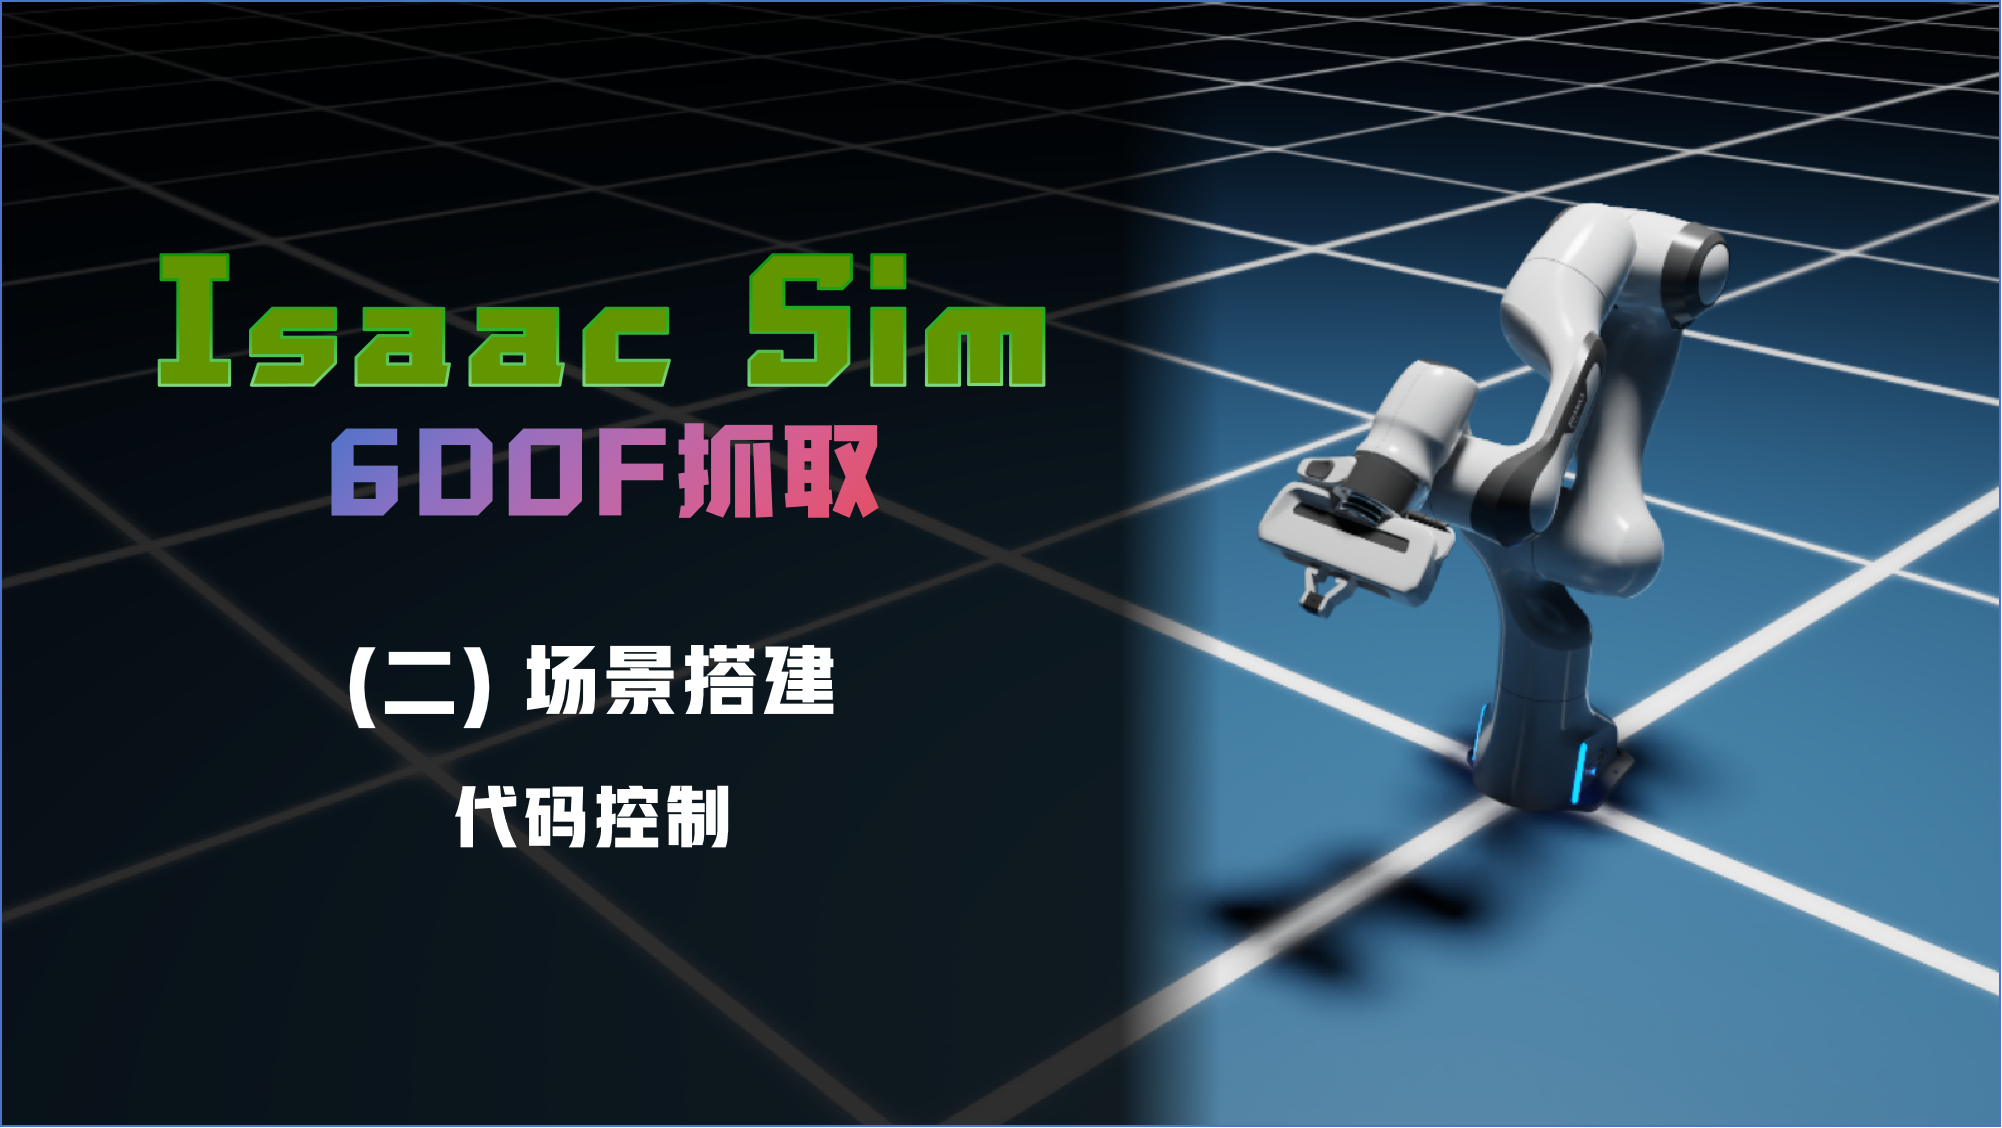

工作流程

1. 使用GUI创建场景
   
    1. 添加需要的物体，
    2. 保存为usd文件
2. 使用python代码
    
    1. 打开usd文件，
    2. 读取仿真中信息(如物体位姿、相机数据)，
    3. 运行算法，
    4. 然后执行机器人动作

> 注意：windows环境notebook不能运行isaacsim，需要运行.py文件

### simple_world
1. 启动应用程序
2. 创建空环境并reset
3. 执行step更新
4. 关闭应用程序

In [ ]:
'''empty_world.py'''

# 不要from isaacsim.simulation_app import SimulationApp 
# isaacsim.模块 是软件内部的api，python解释器会报错说找不到。
# 如下这两行必须在导入模块之前就导入执行
from isaacsim import SimulationApp 
simulation_app = SimulationApp({"headless": False}) 
from isaacsim.core.api import World

world = World()
world.reset()

for i in range(500):
    world.step(render=True) # execute one physics step and one rendering step
simulation_app.close()      # close Isaac Sim

In [ ]:
### 打开usd文件

usd_path = r"用绝对路径" 
from omni.isaac.core.utils.stage import open_stage
open_stage(usd_path)

### 读取prim位姿

from isaacsim.core.prims import SingleXFormPrim
banana = SingleXFormPrim(name="banana", prim_path="/World/banana")

position, orientation = banana.get_world_pose()
print("Banana position is : " + str(position))
print("Banana's orientation is : " + str(orientation))


In [ ]:
'''open_stage.py '''

from isaacsim import SimulationApp 
simulation_app = SimulationApp({"headless": False}) 

from omni.isaac.core.utils.stage import open_stage
from isaacsim.core.api import World
from isaacsim.core.prims import SingleXFormPrim

usd_path = r"F:\Desktop\IsaacSim分享\asset\env.usd" 
open_stage(usd_path)
world = World()

# 创建香蕉的xform对象
banana = SingleXFormPrim(name="banana", prim_path="/World/banana")

# 在获取仿真数据前要调用reset方法，确保环境正确初始化
world.reset()
for i in range(500):
    # 获取香蕉的位姿
    position, orientation = banana.get_world_pose()
    print("Banana position is : " + str(position))
    print("Banana's orientation is : " + str(orientation))
    
    world.step(render=True) 
simulation_app.close()         

In [ ]:
### 控制机器人

# Franka对象是Articulation对象
from isaacsim.robot.manipulators.examples.franka import Franka
# PickPlaceController对象集成了运动学逆解、运动轨迹规划，
#   只需确定抓取点位姿和放置点，即可实现pick_place任务
from isaacsim.robot.manipulators.examples.franka.controllers import PickPlaceController

# world.scene.add 输入Franka对象，返回Franka对象，并将其添加到world管理中
franka:Franka = world.scene.add(Franka(prim_path="/Franka", name="franka")) 
controller = PickPlaceController(
            name="pick_place_controller",
            gripper=franka.gripper,
            robot_articulation=franka,
            # base_link高度+期望夹爪末端距离桌面高度
            end_effector_initial_height=1.0+0.3,
            # events_dt 1/events_dt=时间步数目，越小执行次数越多
            events_dt=[0.008, 0.005, 1, 0.01, 0.05, 0.05, 0.0025, 1, 0.008, 0.08], 
        )

# PickPlaceController的forward函数
actions = controller.forward(
        picking_position=banana_position,
        placing_position=goal_position,
        current_joint_positions=current_joint_positions,
)

# 执行动作
franka.apply_action(actions)


In [ ]:
'''pick_place.py'''

from isaacsim import SimulationApp
simulation_app = SimulationApp({"headless": False})

from omni.isaac.core.utils.stage import open_stage
from isaacsim.core.api import World
from isaacsim.core.prims import SingleXFormPrim

from isaacsim.robot.manipulators.examples.franka import Franka
from isaacsim.robot.manipulators.examples.franka.controllers import PickPlaceController

usd_path = r"F:\Desktop\IsaacSim分享\asset\env.usd" 
open_stage(usd_path)
world = World()
banana = SingleXFormPrim(name="banana", prim_path="/World/banana")

# 创建机器人Articulation和PickPlaceController
franka:Franka = world.scene.add(Franka(prim_path="/Franka", name="franka")) 
controller = PickPlaceController(
            name="pick_place_controller",
            gripper=franka.gripper,
            robot_articulation=franka,
            end_effector_initial_height=1.0+0.3,
            events_dt=[0.008, 0.005, 1, 0.01, 0.05, 0.05, 0.0025, 1, 0.008, 0.08], 
        )

world.reset()
for i in range(50): # 先执行50步仿真，得到物体掉落后稳定
    world.step()

franka.gripper.set_joint_positions(franka.gripper.joint_opened_positions)

# 确定抓取点和放置点
banana_position, banana_orientation = banana.get_world_pose()
banana_position[2] -= 0.01
goal_position = banana_position.copy()
goal_position[0] += 0.2
goal_position[2] += 0.05
print(banana_position)
print(goal_position)

for i in range(1000000):
    # 获取当前机械臂关节位置
    current_joint_positions = franka.get_joint_positions()
    # 计算需要执行的动作
    actions = controller.forward(
            picking_position=banana_position,
            placing_position=goal_position,
            current_joint_positions=current_joint_positions,
    )
    # 执行动作
    franka.apply_action(actions)
    
    world.step(render=True) 
simulation_app.close()     